In [1]:
#!/usr/bin/env python3
"""
Please refer to plotting_cumulative_LoS_vs_GNSS.ipynb for the code and comments.
This is a script version of the notebook for easier execution and sharing.
"""

import os
import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
import datetime as dt
import pandas as pd

sys.path.append("/home/users/mnergiz/softwares/licsar_extra/python")  # adjust as needed

from lics_tstools import load_licsbas_cumh5_as_xrda
from lics_tstools import generate_pmm_velocity
from lics_tstools import load_tif2xr
from plotting_LOS_GNSS import *

# -------------------------
# defining variables
# -------------------------
os.environ["LiCSAR_public"] = "/gws/ssde/j25a/nceo_geohazards/vol1/public/LiCSAR_products.public/"
frame = "021D_05266_252525"
sbovl = False
path = f"/work/scratch-pw4/licsar/mnergiz/TR_postseismic_04042026/range/{frame}"
# path = f"/work/scratch-pw4/licsar/mnergiz/TR_postseismic_01042026/{frame}"
TS_folder = f"{path}/TS_GEOCml10GACOS"
GEOC_folder = os.path.join(os.path.dirname(os.path.normpath(TS_folder)), "GEOCml10GACOS")
cumfile = f"{TS_folder}/cum.h5"
cumfile_filt = f"{TS_folder}/cum_filt.h5"
ref_loc = "KLS1"
point_loc = "EKZ1"

# -------------------------
# loading LoS InSAR
# -------------------------
cum = load_licsbas_cumh5_as_xrda(cumfile)
cum_filt = load_licsbas_cumh5_as_xrda(cumfile_filt)

# -------------------------
# loading GNSS
# -------------------------
gnss_cum = xr.open_dataset(
    "/gws/ssde/j25a/nceo_geohazards/vol2/LiCS/temp/insar_proc/mnergizci/GNSS_Turkey_Ergintav/gnss_nc.nc"
)

gnss_folder = "/gws/ssde/j25a/nceo_geohazards/vol2/LiCS/temp/insar_proc/mnergizci/GNSS_Turkey_Ergintav/output_fits_seasonal_full-04042026/"

gnss_daily = build_deseasonalized_gnss_dataset(
    root_dir=f"{gnss_folder}",
    gnss_cum=gnss_cum,
    csv_pattern="deseasonalized_*.csv",
    verbose=True,
)

gnss_moving = build_deseasonalized_gnss_dataset(
root_dir=f"{gnss_folder}",
gnss_cum=gnss_cum,
csv_pattern="moving_weighted_*.csv",
verbose=True,
)

gnss_daily_ref = reference_gnss_dataset(
    gnss_daily,
    reference_station=ref_loc,
    vars_to_ref=("Ve", "Vn", "Vu"),
    verbose=True,
)

gnss_cum_ref = reference_gnss_dataset(
    gnss_moving,
    reference_station=ref_loc,
    vars_to_ref=("Ve", "Vn", "Vu"),
    verbose=True,
)

# -------------------------
# ENU unit vectors
# -------------------------
if sbovl:
    E_unit = load_tif2xr(f"{path}/{frame}.E.azi.geo.tif")
    N_unit = load_tif2xr(f"{path}/{frame}.N.azi.geo.tif")
    U_unit = xr.zeros_like(E_unit)  # azimuth has no vertical sensitivity
else:
    E_unit = load_tif2xr(f"{path}/{frame}.E.geo.tif")
    N_unit = load_tif2xr(f"{path}/{frame}.N.geo.tif")
    U_unit = load_tif2xr(f"{path}/{frame}.U.geo.tif")

# -------------------------
# GNSS to LoS projection
# -------------------------
gnss_cum_los = project_gnss_to_los(
    gnss_cum_ref,
    E_unit=E_unit,
    N_unit=N_unit,
    U_unit=U_unit,
    method="nearest",
    sboi=False,
    los_name="gnss_los",
    plot_enu=False,
    plot_station=point_loc,
)

gnss_daily_los = project_gnss_to_los(
    gnss_daily_ref,
    E_unit=E_unit,
    N_unit=N_unit,
    U_unit=U_unit,
    method="nearest",
    sboi=False,
    los_name="gnss_los",
    plot_enu=False,
    plot_station=point_loc,
)

# -------------------------
# Extract GNSS LoS at last epoch
# -------------------------
df, t = los_points_at_time(
    gnss_cum_los,
    var="gnss_los",
    t=gnss_cum_los.time.values[-1],
)

# -------------------------
# reference and point coordinates
# -------------------------
reference = get_station_coords(gnss_cum_ref, ref_loc)
point1 = get_station_coords(gnss_cum_ref, point_loc)
#df playing
df = df[(df["v"] != 0) | ((df["lon"] == reference[0]) & (df["lat"] == reference[1]))]    
df = df.dropna().copy()

# -------------------------
# variable names
# -------------------------
vars_to_ref = ["cum"]

# -------------------------
# referencing cumulative LoS
# -------------------------
cum_ref = reference_ts_dataset(
    cum,
    reference=reference,
    vars_to_ref=vars_to_ref,
    use_nearest=True,
    halfwin=4,
    verbose=True,
)

cum_filt_ref = reference_ts_dataset(
    cum_filt,
    reference=reference,
    vars_to_ref=vars_to_ref,
    use_nearest=True,
    halfwin=4,
    verbose=True,
)


# -------------------------
# time in years
# -------------------------
time_years = xr.DataArray(
    (cum.time.values - cum.time.values[0]) / np.timedelta64(1, "D") / 365.25,
    coords={"time": cum.time.values},
    dims=["time"],
)

# -------------------------
# plate motion correction
# -------------------------
vlos_eurasia = generate_pmm_velocity(frame, "Eurasia", "GEOC", azi=sbovl)
vlos_eurasia_reshaped = vlos_eurasia.interp_like(cum.vel)
plate_motion_cumulative = vlos_eurasia_reshaped * time_years

# -------------------------
# interseismic model correction
# -------------------------
ve_gnss_nc = "/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/mnergizci/1.second_paper/interseismic/decomp3d.nc"
vn_gnss_nc = "/gws/ssde/j25a/nceo_geohazards/vol1/projects/COMET/mnergizci/1.second_paper/interseismic/velmap_insars29_sbois0_scalar.nc"

ve_gnss = xr.load_dataset(ve_gnss_nc).Ve
vn_gnss = xr.load_dataset(vn_gnss_nc).Vn
vu_gnss = xr.load_dataset(ve_gnss_nc).Vu

ve_gnss_reshaped = ve_gnss.interp_like(E_unit)
vn_gnss_reshaped = vn_gnss.interp_like(E_unit)
vu_gnss_reshaped = vu_gnss.interp_like(E_unit)

interseismic_velo = ve_gnss_reshaped * E_unit + vn_gnss_reshaped * N_unit + vu_gnss_reshaped * U_unit
interseismic_velo_reshaped = interseismic_velo.interp_like(cum.vel)
interseismic_velo_cumulative = interseismic_velo_reshaped * time_years

# -------------------------
# referencing plate / interseismic
# -------------------------
ds_plate = xr.Dataset({"plate": plate_motion_cumulative})
ds_plate_ref = reference_ts_dataset(
    ds_plate,
    reference=reference,
    vars_to_ref=["plate"],
    use_nearest=True,
    halfwin=4,
    verbose=True,
)

ds_inter = xr.Dataset({"interseismic": interseismic_velo_cumulative})
ds_inter_ref = reference_ts_dataset(
    ds_inter,
    reference=reference,
    vars_to_ref=["interseismic"],
    use_nearest=True,
    halfwin=4,
    verbose=True,
)

plate_motion_cumulative_ref = ds_plate_ref["plate"]
interseismic_velo_cumulative_ref = ds_inter_ref["interseismic"]

cum_corr = cum_ref.cum - plate_motion_cumulative_ref - interseismic_velo_cumulative_ref
cum_filt_corr = cum_filt_ref.cum - plate_motion_cumulative_ref - interseismic_velo_cumulative_ref



snaphu not detected. please install it yourself, e.g. from:
https://web.stanford.edu/group/radar/softwareandlinks/sw/snaphu
setting pyproj data directory
licsar misc not loaded
licsbas not loaded - the amplitude/coherence average/stability will fail


getfattr: Removing leading '/' from absolute path names


getfattr: Removing leading '/' from absolute path names


Loaded ADN2: 695 epochs
Loaded ADY1: 695 epochs
Loaded AGRD: 695 epochs
Loaded AKD1: 695 epochs
Loaded AKHR: 695 epochs
Loaded AKLE: 695 epochs
Loaded AKSI: 695 epochs
Loaded AKSR: 695 epochs
Loaded ALNY: 695 epochs
Loaded AMA1: 695 epochs
Loaded ANK2: 695 epochs
Loaded ANMU: 695 epochs
Loaded APK1: 695 epochs
Loaded ARDH: 695 epochs
Loaded ARTV: 695 epochs
Loaded BASK: 695 epochs
Loaded BEYS: 695 epochs
Skipping BFRA: not found in gnss_cum
Loaded BOG1: 695 epochs
Loaded BOL1: 695 epochs
Loaded BOYT: 695 epochs
Loaded BTMN: 695 epochs
Loaded BYB1: 695 epochs
Loaded CANK: 695 epochs
Loaded CATK: 695 epochs
Skipping CIHA: not found in gnss_cum
Loaded CMLD: 695 epochs
Loaded COR1: 695 epochs
Skipping CYL2: not found in gnss_cum
Loaded CZRE: 695 epochs
Loaded DIV3: 695 epochs
Loaded DIY1: 695 epochs
Loaded DLUC: 695 epochs
Loaded EKZ1: 695 epochs
Loaded ELAZ: 695 epochs
Skipping ELMI: not found in gnss_cum
Loaded ERGN: 695 epochs
Loaded ERZ2: 695 epochs
Loaded ERZR: 695 epochs
Loaded FASA:

In [13]:
point_loc="MLY1"
point1 = get_station_coords(gnss_cum_ref, point_loc)
# cum_ts = extract_ts_window_mean(cum_ref.cum, point1, halfwin=4).values
# cum_filt_ts = extract_ts_window_mean(cum_filt_ref.cum, point1, halfwin=4).values
cum_ts = extract_ts_window_mean(cum_corr, point1, halfwin=4).values
cum_filt_ts = extract_ts_window_mean(cum_filt_corr, point1, halfwin=4).values
time_insar = cum_ref.time.values
gnss_cum_los_ts = gnss_cum_los["gnss_los"].sel(station=point_loc).values
time_cum_gnss = gnss_cum_los.time.values
gnss_daily_los_ts = gnss_daily_los["gnss_los"].sel(station=point_loc).values
time_daily_gnss = gnss_daily_los.time.values


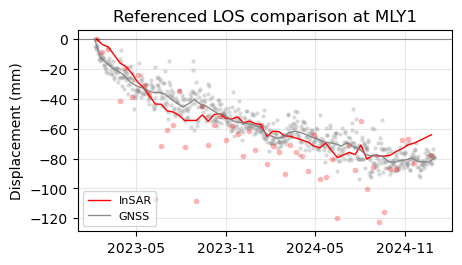

In [15]:
time_insar=time_insar
cum_ts=cum_ts
time_gnss=[time_cum_gnss, time_daily_gnss]
gnss_los_ts=[gnss_cum_los_ts, gnss_daily_los_ts]
point_loc=point_loc
cum_filt_ts=cum_filt_ts

cm = 1 / 2.54  # inches per cm

fig, ax = plt.subplots(1, 1, figsize=(12 * cm, 7 * cm))
plt.rcParams["legend.fontsize"] = 8

# mean_cum = np.nanmean(cum_ts)
# std_cum = np.nanstd(cum_ts)

# mean_gnss_cum = np.nanmean(gnss_los_ts[0])
# std_gnss_cum = np.nanstd(gnss_los_ts[0])
# mean_gnss_daily = np.nanmean(gnss_los_ts[1])
# std_gnss_daily = np.nanstd(gnss_los_ts[1])

ax.plot(
    time_insar,
    cum_ts,
    color="red",
    marker="o",
    linestyle="None",
    markeredgecolor="none",
    alpha=0.3,
    markersize=4,
    # label=f"InSAR",
)

if cum_filt_ts is not None:
    # mean_cum_filt = np.nanmean(cum_filt_ts)
    # std_cum_filt = np.nanstd(cum_filt_ts)
    ax.plot(
        time_insar,
        cum_filt_ts,
        color="red",
        linewidth=1,
        linestyle="-",
        label=f"InSAR",
    )

# shadow (daily GNSS)
ax.plot(
    time_gnss[1],
    gnss_los_ts[1],
    color="0.5",
    marker="o",
    markersize=3,
    linestyle="None",
    alpha=0.3,
    markeredgecolor="none",
    zorder=1,
)

ax.plot(
    time_gnss[0],
    gnss_los_ts[0],
    color="gray",
    linewidth=1,
    linestyle="-",
    zorder=3,
    alpha=0.9,
    label=f"GNSS",
)

ax.set_title(f"Referenced LOS comparison at {point_loc}")
ax.set_ylabel("Displacement (mm)")
ax.axhline(0, color="k", lw=0.8, alpha=0.4)

locator = mdates.MonthLocator(interval=6)
formatter = mdates.DateFormatter("%Y-%m")
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")

fig.tight_layout()

plt.show()

In [ ]:
# -------------------------
# extract time series
# -------------------------
for point_loc in df['station'].values:
    if point_loc != ref_loc:
        point1 = get_station_coords(gnss_cum_ref, point_loc)
        # cum_ts = extract_ts_window_mean(cum_ref.cum, point1, halfwin=4).values
        # cum_filt_ts = extract_ts_window_mean(cum_filt_ref.cum, point1, halfwin=4).values
        cum_ts = extract_ts_window_mean(cum_corr, point1, halfwin=4).values
        cum_filt_ts = extract_ts_window_mean(cum_filt_corr, point1, halfwin=4).values
        time_insar = cum_ref.time.values
        gnss_cum_los_ts = gnss_cum_los["gnss_los"].sel(station=point_loc).values
        time_cum_gnss = gnss_cum_los.time.values
        gnss_daily_los_ts = gnss_daily_los["gnss_los"].sel(station=point_loc).values
        time_daily_gnss = gnss_daily_los.time.values
        # -------------------------
        # LOS comparison plot
        # -------------------------
        plot_los_comparison(
            time_insar=time_insar,
            cum_ts=cum_ts,
            time_gnss=[time_cum_gnss, time_daily_gnss],
            gnss_los_ts=[gnss_cum_los_ts, gnss_daily_los_ts],
            point_loc=point_loc,
            outname=f"los_comparison_{point_loc}.png",
            cum_filt_ts=cum_filt_ts,
        )

# corrected_cum = cum_ref.cum.isel(time=-1)
corrected_cum = (cum_ref.cum.isel(time=-1) - plate_motion_cumulative_ref.isel(time=-1) - interseismic_velo_cumulative_ref.isel(time=-1))
plot_cumulative_pygmt(
    grid=corrected_cum,
    df_stations=df,
    point1=point1,
    reference=reference,
    outname=f"Figure3_cumulativerections_{point_loc}.png",
    grid_label="",
    grid_series=(-150, 150, 1),
)
